In [2]:
# ── Install transformers (Azure ML curated PyTorch envs ship with torch pre-installed) ─
!pip install -q transformers accelerate
%pip install pandas matplotlib seaborn scikit-learn transformers accelerate pillow
%pip install torchvision --index-url https://pytorch.org

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pytorch.org
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install torchvision==0.24.1 --extra-index-url https://pytorch.org --no-deps
import torchvision.transforms as T
print("Success!")


Looking in indexes: https://pypi.org/simple, https://pytorch.org
Note: you may need to restart the kernel to use updated packages.
Success!


In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as T

from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    get_cosine_schedule_with_warmup,
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings('ignore')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-26 09:05:46.522669: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 09:05:46.571831: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 09:05:46.571868: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 09:05:46.573

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"[INFO] GPU  : {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

[INFO] Device: cpu


In [6]:
import os
import argparse

def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--data_dir", type=str,
        default=os.environ.get("AZUREML_DATA_DIR", "./chest_xray"),
        help="Root folder with train/ val/ test/ subfolders (mounted Azure ML Data asset path)."
    )
    parser.add_argument(
        "--output_dir", type=str,
        default=os.environ.get("AZUREML_OUTPUT_DIR", "./outputs"),
        help="Azure ML automatically captures and tracks everything written to ./outputs."
    )
    args, _ = parser.parse_known_args()  # parse_known_args so this also works inside a notebook kernel
    return args

args = get_args()

# ── Azure ML dataset path ─────────────────────────────────────────────────────
BASE_DIR  = args.data_dir
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val")

# Output paths (Azure ML run outputs — captured/tracked automatically)
OUTPUT_DIR = args.output_dir
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_pneumonia_vit.pt")
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "pneumonia_vit_checkpoint.pt")

MODEL_NAME = "google/vit-base-patch16-224-in21k"

# Quick sanity check
for d in [TRAIN_DIR, TEST_DIR, VAL_DIR]:
    assert os.path.isdir(d), f"❌ Directory not found: {d}"
print(f"✅ All dataset directories found under {BASE_DIR}")

✅ All dataset directories found under ./chest_xray


In [7]:
def count_images(folder):
    return len([f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

num_pneu_train = count_images(os.path.join(TRAIN_DIR, 'PNEUMONIA'))
num_norm_train = count_images(os.path.join(TRAIN_DIR, 'NORMAL'))

print("Dataset Statistics")
print("=" * 44)
print(f"  Train  → PNEUMONIA: {num_pneu_train:>4}  |  NORMAL: {num_norm_train:>4}")
print(f"  Test   → PNEUMONIA: {count_images(os.path.join(TEST_DIR,'PNEUMONIA')):>4}  "
      f"|  NORMAL: {count_images(os.path.join(TEST_DIR,'NORMAL')):>4}")
print(f"  Val    → PNEUMONIA: {count_images(os.path.join(VAL_DIR,'PNEUMONIA')):>4}  "
      f"|  NORMAL: {count_images(os.path.join(VAL_DIR,'NORMAL')):>4}")
print(f"  Imbalance ratio   : {num_pneu_train/num_norm_train:.2f}:1")

Dataset Statistics
  Train  → PNEUMONIA: 3875  |  NORMAL: 1341
  Test   → PNEUMONIA:  390  |  NORMAL:  234
  Val    → PNEUMONIA:    8  |  NORMAL:    8
  Imbalance ratio   : 2.89:1


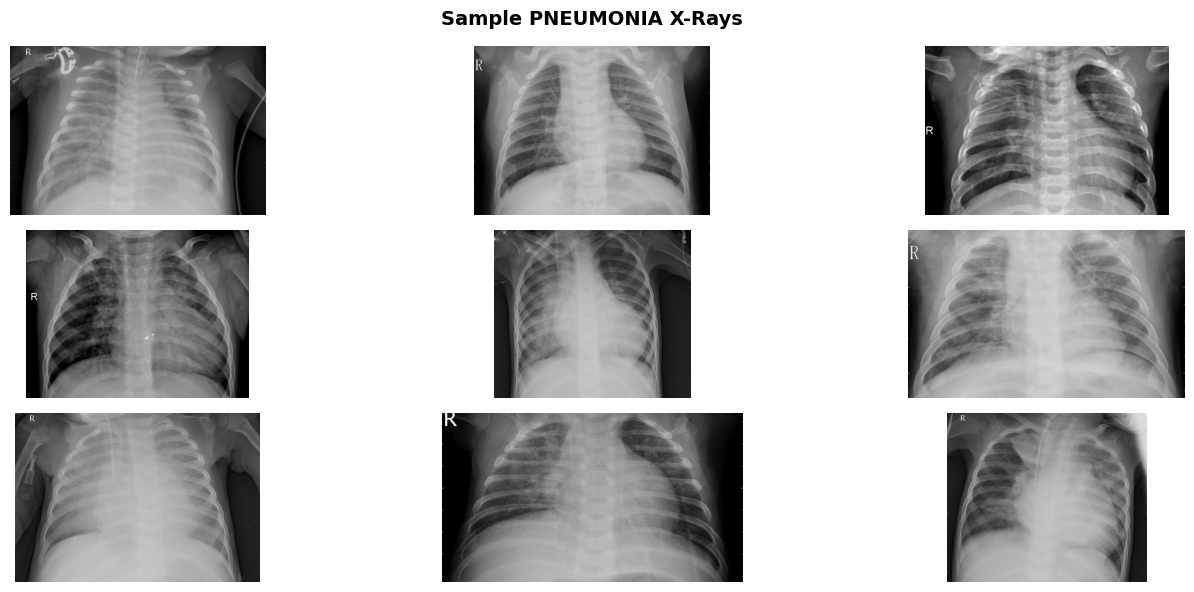

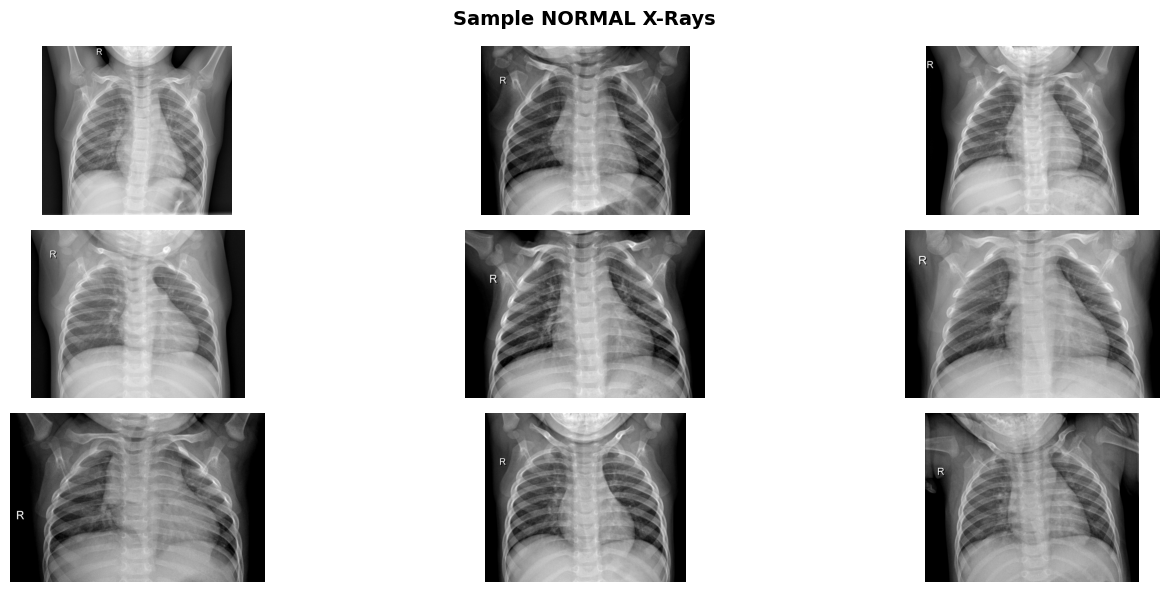

In [8]:
def show_sample_images(folder_path, title, n=9):
    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:n]
    plt.figure(figsize=(15, 6))
    plt.suptitle(title, fontsize=14, fontweight='bold')
    for i, fname in enumerate(files):
        plt.subplot(3, 3, i + 1)
        img = plt.imread(os.path.join(folder_path, fname))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(os.path.join(TRAIN_DIR, 'PNEUMONIA'), 'Sample PNEUMONIA X-Rays')
show_sample_images(os.path.join(TRAIN_DIR, 'NORMAL'),    'Sample NORMAL X-Rays')

In [12]:
print(f"[INFO] Loading ViT processor from '{MODEL_NAME}'…")
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

IMG_MEAN = processor.image_mean   # [0.5, 0.5, 0.5]
IMG_STD  = processor.image_std    # [0.5, 0.5, 0.5]
IMG_SIZE = processor.size["height"]  # 224

# ── Train augmentation ────────────────────────────────────────────────────────
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ── Eval transform ────────────────────────────────────────────────────────────
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

print(f"[INFO] Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"[INFO] Mean: {IMG_MEAN}  |  Std: {IMG_STD}")

[INFO] Loading ViT processor from 'google/vit-base-patch16-224-in21k'…
[INFO] Image size: 224x224
[INFO] Mean: [0.5, 0.5, 0.5]  |  Std: [0.5, 0.5, 0.5]


In [13]:
class XRayDataset(Dataset):
    """Loads X-ray images. Labels: NORMAL=0, PNEUMONIA=1"""
    LABEL_MAP = {'NORMAL': 0, 'PNEUMONIA': 1}

    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for class_name, label in self.LABEL_MAP.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, fname), label))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

In [14]:
# ── Kaggle GPU has 16 GB VRAM; batch 32 is fine ───────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2   # Kaggle supports multiprocessing; 2 is safe

train_dataset = XRayDataset(TRAIN_DIR, transform=train_transform)
val_dataset   = XRayDataset(VAL_DIR,   transform=eval_transform)
test_dataset  = XRayDataset(TEST_DIR,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)

print(f"[INFO] Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  "
      f"|  Test: {len(test_dataset)}")

[INFO] Train: 5216  |  Val: 16  |  Test: 624


In [15]:
total       = num_pneu_train + num_norm_train
w_normal    = total / (2.0 * num_norm_train)
w_pneumonia = total / (2.0 * num_pneu_train)
pos_weight  = torch.tensor([w_pneumonia / w_normal], dtype=torch.float32).to(DEVICE)

print(f"[INFO] Class weights → NORMAL: {w_normal:.3f}  |  PNEUMONIA: {w_pneumonia:.3f}")
print(f"[INFO] BCEWithLogitsLoss pos_weight: {pos_weight.item():.3f}")

[INFO] Class weights → NORMAL: 1.945  |  PNEUMONIA: 0.673
[INFO] BCEWithLogitsLoss pos_weight: 0.346


In [16]:
print(f"[INFO] Loading ViT model from '{MODEL_NAME}'…")
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    ignore_mismatched_sizes=True,
)

# Replace with a 3-layer head (hidden_size=768 for ViT-Base)
model.classifier = nn.Sequential(
    nn.Linear(model.config.hidden_size, 256),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(256, 64),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Total params    : {total_params:,}")
print(f"[INFO] Trainable params: {trainable_params:,}")

[INFO] Loading ViT model from 'google/vit-base-patch16-224-in21k'…
[INFO] Total params    : 86,012,033
[INFO] Trainable params: 86,012,033


In [17]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Freeze / Unfreeze helpers ─────────────────────────────────────────────────
def freeze_vit_encoder(model):
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[PHASE 1] Encoder frozen. Trainable params: {n:,} (head only)")

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[PHASE 2] All layers unfrozen. Trainable params: {n:,}")

# ── Single epoch runner ───────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None,
              train=True, threshold=0.5, scheduler=None):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(pixel_values=imgs).logits.squeeze(1)
            loss   = criterion(logits, labels)

            if train and optimizer:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()   # step-level scheduler for Phase 2

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)
            lbls  = labels.detach().cpu().numpy().astype(int)

            total_loss += loss.item() * len(labels)
            correct    += (preds == lbls).sum()
            total      += len(labels)
            all_probs.extend(probs.tolist())
            all_labels.extend(lbls.tolist())

    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = float('nan')
    return avg_loss, float(accuracy), auc, all_probs, all_labels

In [18]:
EPOCHS_PHASE1 = 5
PATIENCE      = 6
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_pneumonia_vit.pt")
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_auc':  [], 'val_auc':  [],
}
best_val_auc = 0.0
best_epoch   = 0

print("=" * 60)
print("PHASE 1 — Head warm-up (encoder frozen)")
print("=" * 60)
freeze_vit_encoder(model)

optimizer_p1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01
)
scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=EPOCHS_PHASE1)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p1, train=True)
    vl_loss, vl_acc, vl_auc, _, _ = run_epoch(
        model, val_loader,   criterion, train=False)
    scheduler_p1.step()   # epoch-level

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)

    print(f"  Epoch {epoch:02d}/{EPOCHS_PHASE1} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
          f"AUC {tr_auc:.3f}/{vl_auc:.3f}")

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        best_epoch = epoch
        print(f"    ✓ Saved (best val AUC: {best_val_auc:.4f})")

PHASE 1 — Head warm-up (encoder frozen)
[PHASE 1] Encoder frozen. Trainable params: 213,377 (head only)
  Epoch 01/5 | Loss 0.1790/0.3312 | Acc 0.828/0.812 | AUC 0.924/1.000
    ✓ Saved (best val AUC: 1.0000)
  Epoch 02/5 | Loss 0.1062/0.4115 | Acc 0.914/0.688 | AUC 0.974/1.000
  Epoch 03/5 | Loss 0.0836/0.3818 | Acc 0.937/0.688 | AUC 0.983/0.969
  Epoch 04/5 | Loss 0.0755/0.2522 | Acc 0.942/0.812 | AUC 0.986/0.969
  Epoch 05/5 | Loss 0.0724/0.2008 | Acc 0.945/0.875 | AUC 0.987/0.969


In [19]:
print("=" * 60)
print("PHASE 2 — Full fine-tuning (all layers)")
print("=" * 60)
for name, param in model.named_parameters():
    param.requires_grad = False
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name or "classifier" in name:
        param.requires_grad = True
EPOCHS_PHASE2 = 2
optimizer_p2 = AdamW([
    {'params': [p for n, p in model.named_parameters()
                if 'classifier' not in n], 'lr': 5e-6},   # ViT encoder: tiny LR
    {'params': model.classifier.parameters(),             # Head: larger LR
     'lr': 1e-4},
], weight_decay=0.01)

total_steps  = EPOCHS_PHASE2 * len(train_loader)
warmup_steps = total_steps // 10
scheduler_p2 = get_cosine_schedule_with_warmup(
    optimizer_p2,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

patience_ctr = 0

for epoch in range(1, EPOCHS_PHASE2 + 1):
    # Pass scheduler so run_epoch steps it after every batch
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p2,
        train=True, threshold=0.5, scheduler=scheduler_p2)
    vl_loss, vl_acc, vl_auc, _, _ = run_epoch(
        model, val_loader, criterion, train=False, threshold=0.5)

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)

    improved = vl_auc > best_val_auc
    if improved:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        best_epoch   = EPOCHS_PHASE1 + epoch
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"  Epoch {EPOCHS_PHASE1+epoch:02d} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
          f"AUC {tr_auc:.3f}/{vl_auc:.3f}"
          + (" ✓" if improved else ""))

    if patience_ctr >= PATIENCE:
        print(f"\n[INFO] Early stopping triggered at epoch {EPOCHS_PHASE1+epoch}")
        break

print(f"\n[INFO] Best model from epoch {best_epoch} (val AUC = {best_val_auc:.4f})")    

PHASE 2 — Full fine-tuning (all layers)
  Epoch 06 | Loss 0.0721/0.3428 | Acc 0.949/0.750 | AUC 0.988/0.953
  Epoch 07 | Loss 0.0630/0.2853 | Acc 0.951/0.812 | AUC 0.990/0.953

[INFO] Best model from epoch 1 (val AUC = 1.0000)


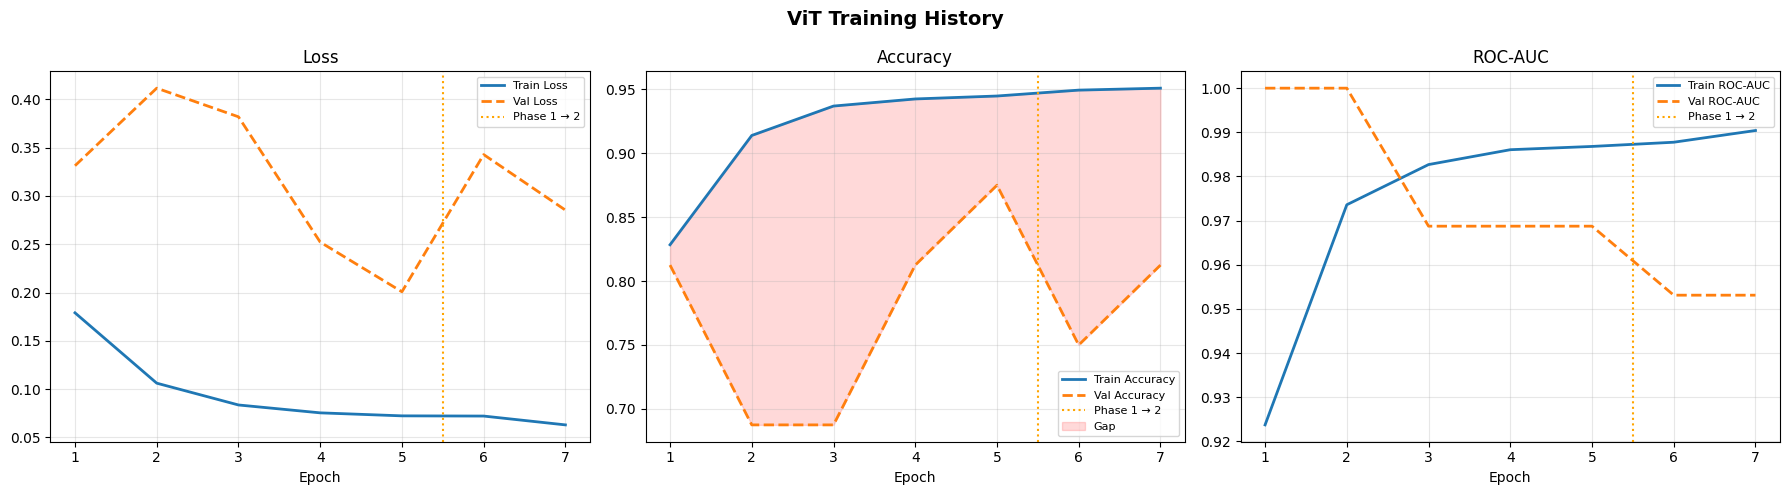


── Gap Analysis (best epoch = 1) ──
  Train acc : 0.8284  (82.8%)
  Val acc   : 0.8125  (81.2%)
  Gap       : 0.0159  (1.6%)
  ✓ < 5% — well generalised


In [20]:
def plot_history(h, phase1_epochs):
    ep  = range(1, len(h['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('ViT Training History', fontsize=14, fontweight='bold')

    for ax, (tr_key, vl_key, title) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('train_auc',  'val_auc',  'ROC-AUC'),
    ]):
        ax.plot(ep, h[tr_key], label=f'Train {title}', lw=2)
        ax.plot(ep, h[vl_key], label=f'Val {title}',   lw=2, ls='--')
        ax.axvline(phase1_epochs + 0.5, color='orange', ls=':', lw=1.5,
                   label='Phase 1 → 2')
        if title == 'Accuracy':
            ax.fill_between(ep, h[vl_key], h[tr_key],
                            alpha=0.15, color='red', label='Gap')
        ax.set_title(title); ax.legend(fontsize=8)
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()

    best = int(np.argmax(h['val_auc']))
    tr_a = h['train_acc'][best]
    vl_a = h['val_acc'][best]
    gap  = tr_a - vl_a
    print(f"\n── Gap Analysis (best epoch = {best+1}) ──")
    print(f"  Train acc : {tr_a:.4f}  ({tr_a*100:.1f}%)")
    print(f"  Val acc   : {vl_a:.4f}  ({vl_a*100:.1f}%)")
    print(f"  Gap       : {gap:.4f}  ({gap*100:.1f}%)")
    print("  " + ("✓ < 5% — well generalised" if gap < 0.05
                  else "⚠ 5-10% — mild overfit" if gap < 0.10
                  else "✗ > 10% — overfit, increase dropout or L2"))

plot_history(history, EPOCHS_PHASE1)

In [21]:
print("[INFO] Loading best saved weights…")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))

_, _, _, val_probs, val_labels = run_epoch(
    model, val_loader, criterion, train=False, threshold=0.5)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)
best_thresh_idx  = np.argmax(f1_scores)
chosen_threshold = float(thresholds[best_thresh_idx])

print(f"[INFO] Optimal threshold (max F1 on val): {chosen_threshold:.3f}")
print(f"       Precision: {precisions[best_thresh_idx]:.3f}  "
      f"Recall: {recalls[best_thresh_idx]:.3f}  "
      f"F1: {f1_scores[best_thresh_idx]:.3f}")

[INFO] Loading best saved weights…
[INFO] Optimal threshold (max F1 on val): 0.773
       Precision: 1.000  Recall: 1.000  F1: 1.000


In [22]:
print("── Test Set Evaluation ──────────────────────────")
_, test_acc, test_auc, test_probs, test_labels = run_epoch(
    model, test_loader, criterion, train=False, threshold=chosen_threshold)
test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)

print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test ROC-AUC  : {test_auc:.4f}")

── Test Set Evaluation ──────────────────────────
  Test Accuracy : 87.34%
  Test ROC-AUC  : 0.9452



  Threshold = 0.773

Confusion Matrix:
[[210  24]
 [ 55 335]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.79      0.90      0.84       234
   PNEUMONIA       0.93      0.86      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.88      0.87       624
weighted avg       0.88      0.87      0.87       624

  False Positive Rate (NORMAL → PNEUMONIA) : 10.26%
  False Negative Rate (PNEUMONIA → NORMAL) : 14.10%


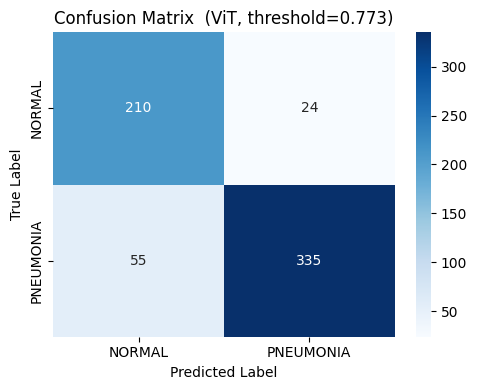


  Threshold = 0.5

Confusion Matrix:
[[170  64]
 [ 27 363]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.73      0.79       234
   PNEUMONIA       0.85      0.93      0.89       390

    accuracy                           0.85       624
   macro avg       0.86      0.83      0.84       624
weighted avg       0.85      0.85      0.85       624

  False Positive Rate (NORMAL → PNEUMONIA) : 27.35%
  False Negative Rate (PNEUMONIA → NORMAL) : 6.92%


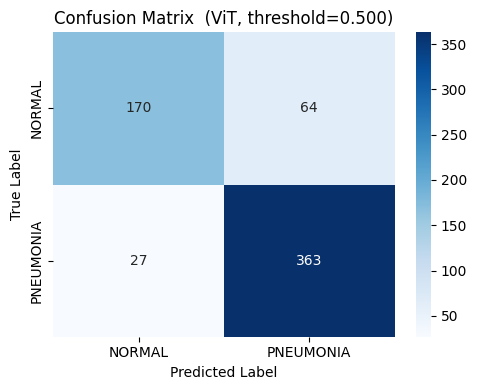

In [23]:
for thr in sorted({0.5, round(chosen_threshold, 3)}, reverse=True):
    preds  = (test_probs >= thr).astype(int)
    cm     = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds,
                                   target_names=['NORMAL', 'PNEUMONIA'])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"\n{'='*52}\n  Threshold = {thr}\n{'='*52}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{report}")
    print(f"  False Positive Rate (NORMAL → PNEUMONIA) : {fpr:.2%}")
    print(f"  False Negative Rate (PNEUMONIA → NORMAL) : {fnr:.2%}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.title(f'Confusion Matrix  (ViT, threshold={thr:.3f})')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_thr_{str(thr).replace(".","_")}.png'), dpi=150)
    plt.show()

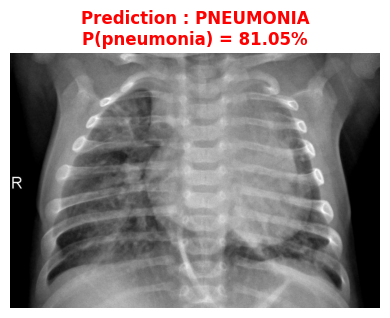

Predicted  : PNEUMONIA
Probability: 0.8105
Threshold  : 0.773


('PNEUMONIA', 0.8105148077011108)

In [24]:
def predict_single_image(image_path: str, threshold: float = None):
    if threshold is None:
        threshold = chosen_threshold

    img    = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logit = model(pixel_values=tensor).logits.squeeze()
        prob  = torch.sigmoid(logit).item()

    label = 'PNEUMONIA' if prob >= threshold else 'NORMAL'
    color = 'red' if label == 'PNEUMONIA' else 'green'

    plt.figure(figsize=(4, 4))
    plt.imshow(np.array(img), cmap='gray')
    plt.axis('off')
    plt.title(f"Prediction : {label}\nP(pneumonia) = {prob:.2%}",
              fontsize=12, color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Predicted  : {label}")
    print(f"Probability: {prob:.4f}")
    print(f"Threshold  : {threshold:.3f}")
    return label, prob

# ── Example: pick a random test image ────────────────────────────────────────
sample_img = os.path.join(TEST_DIR, 'PNEUMONIA',
             os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])
predict_single_image(sample_img)

In [25]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_name':       MODEL_NAME,
    'threshold':        chosen_threshold,
    'img_size':         IMG_SIZE,
    'img_mean':         IMG_MEAN,
    'img_std':          IMG_STD,
    'test_accuracy':    test_acc,
    'test_auc':         test_auc,
}
torch.save(checkpoint, CHECKPOINT_PATH)

print(f"\n[INFO] Full checkpoint saved → {CHECKPOINT_PATH}")
print(f"       Threshold: {chosen_threshold:.3f}")
print(f"       Test Acc : {test_acc*100:.2f}%")
print(f"       Test AUC : {test_auc:.4f}")
print(f"\n[INFO] Find outputs in {OUTPUT_DIR} → Azure ML tracks this folder automatically for the run.")


[INFO] Full checkpoint saved → ./outputs/pneumonia_vit_checkpoint.pt
       Threshold: 0.773
       Test Acc : 87.34%
       Test AUC : 0.9452

[INFO] Find outputs in ./outputs → Azure ML tracks this folder automatically for the run.
